# 🔗 Phase 1B: Sensor Fusion for Activity Recognition
## Combining Phone + Watch Data for Improved Accuracy

**Project:** Goal-Aware, Activity-Driven Personalized Nutrition Recommendation System

This notebook implements **sensor fusion** strategies:

| Strategy | Description |
|----------|-------------|
| **Feature-Level Fusion** | Concatenate features from multiple sensors |
| **Decision-Level Fusion** | Ensemble predictions from individual models |

### Fusion Combinations
1. Phone (Accel + Gyro)
2. Watch (Accel + Gyro)
3. Phone + Watch (All Sensors)

---

In [1]:
# Run the setup notebook first
%run colab_setup.ipynb

Successfully connected to local path: c:\Users\joshw\OneDrive\Desktop\FYP_Work
📁 Configured Paths:
   Dataset Root: c:\Users\joshw\OneDrive\Desktop\FYP_Work\Datasets/wisdm-dataset
   Models: c:\Users\joshw\OneDrive\Desktop\FYP_Work\Models
   Phone Accel: c:\Users\joshw\OneDrive\Desktop\FYP_Work\Datasets/wisdm-dataset/raw/phone/accel
   Phone Gyro: c:\Users\joshw\OneDrive\Desktop\FYP_Work\Datasets/wisdm-dataset/raw/phone/gyro
   Watch Accel: c:\Users\joshw\OneDrive\Desktop\FYP_Work\Datasets/wisdm-dataset/raw/watch/accel
   Watch Gyro: c:\Users\joshw\OneDrive\Desktop\FYP_Work\Datasets/wisdm-dataset/raw/watch/gyro
All libraries imported successfully!

 Package Versions:
   NumPy: 2.4.1
   Pandas: 2.3.3
   XGBoost: 3.1.3
   LightGBM: 4.6.0
   SHAP: 0.50.0
WISDM Activity Labels:
   ⭐ A: Walking
   ⭐ B: Jogging
      C: Stairs
   ⭐ D: Sitting
   ⭐ E: Standing
      F: Typing
      G: Brushing Teeth
      H: Eating Soup
      I: Eating Chips
      J: Eating Pasta
      K: Drinking
      L: Ea

In [2]:
# Additional imports for fusion
from sklearn.ensemble import VotingClassifier
from collections import Counter

print("✅ Additional imports loaded!")

✅ Additional imports loaded!


## 1. 📊 Load All Sensor Data

In [3]:
# Load all WISDM data
wisdm_data = load_all_wisdm_data()

# Filter to primary activities
PRIMARY_ACTIVITIES = ['A', 'B', 'D', 'E']

def filter_primary(data):
    filtered = {}
    for key, df in data.items():
        if not df.empty:
            filtered[key] = df[df['activity'].isin(PRIMARY_ACTIVITIES)].copy()
    return filtered

primary_data = filter_primary(wisdm_data)

print("\n📊 Data Summary:")
for key, df in primary_data.items():
    print(f"   {key}: {len(df):,} samples")

Loading WISDM Dataset...



Loading watch gyro: 100%|██████████| 51/51 [00:10<00:00,  4.86it/s]



Data Loading Complete!

Dataset Summary:
   phone_accel: 4,804,403 samples, 51 subjects
   phone_gyro: 3,608,635 samples, 51 subjects
   watch_accel: 3,777,046 samples, 51 subjects
   watch_gyro: 3,440,342 samples, 51 subjects

📊 Data Summary:
   phone_accel: 1,082,422 samples
   phone_gyro: 808,892 samples
   watch_accel: 845,829 samples
   watch_gyro: 769,517 samples


## 2. 🔧 Create Windows and Extract Features for All Sensors

In [4]:
WINDOW_SIZE = 200
STEP_SIZE = 100

def process_sensor(df, sensor_name):
    """
    Process a single sensor: create windows and extract features.
    Returns features, labels, and subjects arrays.
    """
    if df.empty:
        return None, None, None
    
    print(f"   Processing {sensor_name}...")
    windows, labels, subjects = create_sliding_windows(df, WINDOW_SIZE, STEP_SIZE)
    
    if len(windows) == 0:
        return None, None, None
    
    features = extract_features(windows)
    features = features.replace([np.inf, -np.inf], np.nan).fillna(0)
    
    # Rename columns with sensor prefix
    features.columns = [f"{sensor_name}_{col}" for col in features.columns]
    
    print(f"      Windows: {len(windows)}, Features: {features.shape[1]}")
    return features, labels, subjects

# Process all sensors
print("\n🔧 Processing all sensors...\n")

sensor_features = {}
sensor_labels = {}
sensor_subjects = {}

for sensor_key in ['phone_accel', 'phone_gyro', 'watch_accel', 'watch_gyro']:
    if sensor_key in primary_data:
        features, labels, subjects = process_sensor(primary_data[sensor_key], sensor_key)
        if features is not None:
            sensor_features[sensor_key] = features
            sensor_labels[sensor_key] = labels
            sensor_subjects[sensor_key] = subjects

print("\n✅ All sensors processed!")


🔧 Processing all sensors...

   Processing phone_accel...


Extracting features: 100%|██████████| 10518/10518 [00:55<00:00, 189.56it/s]


      Windows: 10518, Features: 58
   Processing phone_gyro...


Extracting features: 100%|██████████| 7768/7768 [00:30<00:00, 256.57it/s]


      Windows: 7768, Features: 58
   Processing watch_accel...


Extracting features: 100%|██████████| 8227/8227 [00:32<00:00, 256.90it/s]


      Windows: 8227, Features: 58
   Processing watch_gyro...


Extracting features: 100%|██████████| 7438/7438 [00:28<00:00, 260.60it/s]


      Windows: 7438, Features: 58

✅ All sensors processed!


## 3. 🔗 Feature-Level Fusion Functions

In [5]:
def align_sensor_data(sensors_to_fuse, sensor_features, sensor_labels, sensor_subjects):
    """
    Align data from multiple sensors by finding common subjects and matching windows.
    This is necessary because different sensors may have different numbers of windows.
    
    For simplicity, we'll use a subject-level alignment approach:
    - Find subjects present in all sensors
    - For each subject, take the minimum number of windows across sensors
    """
    # Find common subjects
    common_subjects = None
    for sensor in sensors_to_fuse:
        subjects_set = set(sensor_subjects[sensor])
        if common_subjects is None:
            common_subjects = subjects_set
        else:
            common_subjects = common_subjects.intersection(subjects_set)
    
    common_subjects = sorted(list(common_subjects))
    print(f"   Common subjects: {len(common_subjects)}")
    
    # Collect aligned data
    aligned_features = []
    aligned_labels = []
    aligned_subjects = []
    
    for subject in common_subjects:
        # Get indices for this subject in each sensor
        sensor_indices = {}
        min_windows = float('inf')
        
        for sensor in sensors_to_fuse:
            indices = np.where(sensor_subjects[sensor] == subject)[0]
            sensor_indices[sensor] = indices
            min_windows = min(min_windows, len(indices))
        
        # Take first min_windows from each sensor
        for i in range(min_windows):
            combined_features = []
            label = None
            
            for sensor in sensors_to_fuse:
                idx = sensor_indices[sensor][i]
                combined_features.append(sensor_features[sensor].iloc[idx].values)
                if label is None:
                    label = sensor_labels[sensor][idx]
            
            aligned_features.append(np.concatenate(combined_features))
            aligned_labels.append(label)
            aligned_subjects.append(subject)
    
    # Get combined column names
    combined_columns = []
    for sensor in sensors_to_fuse:
        combined_columns.extend(sensor_features[sensor].columns.tolist())
    
    X = pd.DataFrame(aligned_features, columns=combined_columns)
    y = np.array(aligned_labels)
    subjects = np.array(aligned_subjects)
    
    return X, y, subjects

print("✅ Alignment function defined!")

✅ Alignment function defined!


In [6]:
def train_fusion_model(X, y, subjects, fusion_name):
    """
    Train a fusion model with the combined features.
    """
    print(f"\n{'='*60}")
    print(f"🔗 FUSION: {fusion_name.upper()}")
    print(f"{'='*60}")
    print(f"   Total samples: {len(X)}")
    print(f"   Total features: {X.shape[1]}")
    
    # Encode labels
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    print(f"   Classes: {le.classes_}")
    
    # Subject-wise split
    unique_subjects = np.unique(subjects)
    train_subjects, test_subjects = train_test_split(
        unique_subjects, test_size=0.2, random_state=42
    )
    
    train_mask = np.isin(subjects, train_subjects)
    test_mask = np.isin(subjects, test_subjects)
    
    X_train, X_test = X[train_mask], X[test_mask]
    y_train, y_test = y_encoded[train_mask], y_encoded[test_mask]
    
    print(f"   Train: {len(X_train)} samples")
    print(f"   Test: {len(X_test)} samples")
    
    # Scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train models
    print(f"\n   Training models...")
    models = {
        'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        'XGBoost': xgb.XGBClassifier(
            n_estimators=100, max_depth=6, learning_rate=0.1,
            random_state=42, use_label_encoder=False,
            eval_metric='mlogloss', n_jobs=-1
        ),
        'LightGBM': lgb.LGBMClassifier(
            n_estimators=100, max_depth=6, learning_rate=0.1,
            random_state=42, n_jobs=-1, verbose=-1
        )
    }
    
    results = {}
    for name, model in models.items():
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        
        results[name] = {'model': model, 'accuracy': acc, 'f1': f1, 'predictions': y_pred}
        print(f"      {name}: Acc={acc:.4f}, F1={f1:.4f}")
    
    # Best model
    best_name = max(results, key=lambda x: results[x]['f1'])
    best_model = results[best_name]['model']
    best_f1 = results[best_name]['f1']
    best_acc = results[best_name]['accuracy']
    
    print(f"\n   🏆 Best: {best_name} (F1: {best_f1:.4f})")
    
    # Save model
    model_dir = f'har_fusion_{fusion_name}'
    save_model(best_model, model_dir, scaler, le)
    joblib.dump(list(X.columns), os.path.join(MODELS_PATH, model_dir, 'feature_names.joblib'))
    
    config = {
        'fusion_name': fusion_name,
        'best_model': best_name,
        'accuracy': best_acc,
        'f1_score': best_f1,
        'n_features': X.shape[1],
        'classes': list(le.classes_)
    }
    joblib.dump(config, os.path.join(MODELS_PATH, model_dir, 'training_config.joblib'))
    
    return {
        'fusion_name': fusion_name,
        'best_model_name': best_name,
        'best_model': best_model,
        'accuracy': best_acc,
        'f1': best_f1,
        'scaler': scaler,
        'label_encoder': le,
        'X_test': X_test_scaled,
        'y_test': y_test,
        'y_pred': results[best_name]['predictions'],
        'all_results': results
    }

print("✅ Fusion training function defined!")

✅ Fusion training function defined!


## 4. 🔗 Train Fusion Models

### Fusion 1: Phone Only (Accel + Gyro)

In [7]:
# Fusion 1: Phone Accel + Phone Gyro
print("\n📱 PHONE FUSION (Accel + Gyro)")
print("-" * 40)

phone_sensors = ['phone_accel', 'phone_gyro']
available_phone = [s for s in phone_sensors if s in sensor_features]

if len(available_phone) == 2:
    X_phone, y_phone, subjects_phone = align_sensor_data(
        available_phone, sensor_features, sensor_labels, sensor_subjects
    )
    phone_fusion_result = train_fusion_model(X_phone, y_phone, subjects_phone, 'phone')
else:
    print(f"⚠️ Not all phone sensors available: {available_phone}")
    phone_fusion_result = None


📱 PHONE FUSION (Accel + Gyro)
----------------------------------------
   Common subjects: 51

🔗 FUSION: PHONE
   Total samples: 7768
   Total features: 116
   Classes: ['A' 'B' 'D' 'E']
   Train: 6120 samples
   Test: 1648 samples

   Training models...
      RandomForest: Acc=0.9266, F1=0.9262
      XGBoost: Acc=0.9138, F1=0.9136
      LightGBM: Acc=0.9211, F1=0.9209

   🏆 Best: RandomForest (F1: 0.9262)
✅ Model saved to: c:\Users\joshw\OneDrive\Desktop\FYP_Work\Models\har_fusion_phone


### Fusion 2: Watch Only (Accel + Gyro)

In [8]:
# Fusion 2: Watch Accel + Watch Gyro
print("\n⌚ WATCH FUSION (Accel + Gyro)")
print("-" * 40)

watch_sensors = ['watch_accel', 'watch_gyro']
available_watch = [s for s in watch_sensors if s in sensor_features]

if len(available_watch) == 2:
    X_watch, y_watch, subjects_watch = align_sensor_data(
        available_watch, sensor_features, sensor_labels, sensor_subjects
    )
    watch_fusion_result = train_fusion_model(X_watch, y_watch, subjects_watch, 'watch')
else:
    print(f"⚠️ Not all watch sensors available: {available_watch}")
    watch_fusion_result = None


⌚ WATCH FUSION (Accel + Gyro)
----------------------------------------
   Common subjects: 51

🔗 FUSION: WATCH
   Total samples: 7438
   Total features: 116
   Classes: ['A' 'B' 'D' 'E']
   Train: 5918 samples
   Test: 1520 samples

   Training models...
      RandomForest: Acc=0.9171, F1=0.9170
      XGBoost: Acc=0.9283, F1=0.9282
      LightGBM: Acc=0.9401, F1=0.9400

   🏆 Best: LightGBM (F1: 0.9400)
✅ Model saved to: c:\Users\joshw\OneDrive\Desktop\FYP_Work\Models\har_fusion_watch


### Fusion 3: Full Fusion (Phone + Watch, All Sensors)

In [9]:
# Fusion 3: All sensors
print("\n📱⌚ FULL FUSION (Phone + Watch, All Sensors)")
print("-" * 40)

all_sensors = ['phone_accel', 'phone_gyro', 'watch_accel', 'watch_gyro']
available_all = [s for s in all_sensors if s in sensor_features]

if len(available_all) == 4:
    X_all, y_all, subjects_all = align_sensor_data(
        available_all, sensor_features, sensor_labels, sensor_subjects
    )
    full_fusion_result = train_fusion_model(X_all, y_all, subjects_all, 'full')
else:
    print(f"⚠️ Not all sensors available: {available_all}")
    full_fusion_result = None


📱⌚ FULL FUSION (Phone + Watch, All Sensors)
----------------------------------------
   Common subjects: 51

🔗 FUSION: FULL
   Total samples: 7106
   Total features: 232
   Classes: ['A' 'B' 'D' 'E']
   Train: 5610 samples
   Test: 1496 samples

   Training models...
      RandomForest: Acc=0.9372, F1=0.9363
      XGBoost: Acc=0.9211, F1=0.9206
      LightGBM: Acc=0.9178, F1=0.9172

   🏆 Best: RandomForest (F1: 0.9363)
✅ Model saved to: c:\Users\joshw\OneDrive\Desktop\FYP_Work\Models\har_fusion_full


## 5. 📊 Compare All Approaches

In [10]:
# Load individual sensor results if available
try:
    phase1_summary = joblib.load(os.path.join(MODELS_PATH, 'phase1_summary.joblib'))
    individual_results = phase1_summary['all_sensors']
except:
    print("⚠️ Phase 1 summary not found. Run phase1_complete_har_training.ipynb first.")
    individual_results = {}

# Collect all results
comparison_data = []

# Add individual sensor results
for sensor, result in individual_results.items():
    comparison_data.append({
        'Approach': sensor.replace('_', ' ').title(),
        'Type': 'Individual',
        'Best Model': result['best_model'],
        'Accuracy': result['accuracy'],
        'F1 Score': result['f1_score']
    })

# Add fusion results
if phone_fusion_result:
    comparison_data.append({
        'Approach': 'Phone Fusion',
        'Type': 'Fusion',
        'Best Model': phone_fusion_result['best_model_name'],
        'Accuracy': phone_fusion_result['accuracy'],
        'F1 Score': phone_fusion_result['f1']
    })

if watch_fusion_result:
    comparison_data.append({
        'Approach': 'Watch Fusion',
        'Type': 'Fusion',
        'Best Model': watch_fusion_result['best_model_name'],
        'Accuracy': watch_fusion_result['accuracy'],
        'F1 Score': watch_fusion_result['f1']
    })

if full_fusion_result:
    comparison_data.append({
        'Approach': 'Full Fusion (All)',
        'Type': 'Fusion',
        'Best Model': full_fusion_result['best_model_name'],
        'Accuracy': full_fusion_result['accuracy'],
        'F1 Score': full_fusion_result['f1']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('F1 Score', ascending=False)

print("\n" + "="*80)
print("📊 COMPLETE COMPARISON: Individual vs Fusion")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)


📊 COMPLETE COMPARISON: Individual vs Fusion
         Approach       Type   Best Model  Accuracy  F1 Score
     Watch Fusion     Fusion     LightGBM  0.940132  0.940032
Full Fusion (All)     Fusion RandomForest  0.937166  0.936336
     Phone Fusion     Fusion RandomForest  0.926578  0.926219
       Watch Gyro Individual     LightGBM  0.901974  0.901886
      Phone Accel Individual     LightGBM  0.897219  0.896554
      Watch Accel Individual      XGBoost  0.867698  0.866262
       Phone Gyro Individual RandomForest  0.810073  0.809908


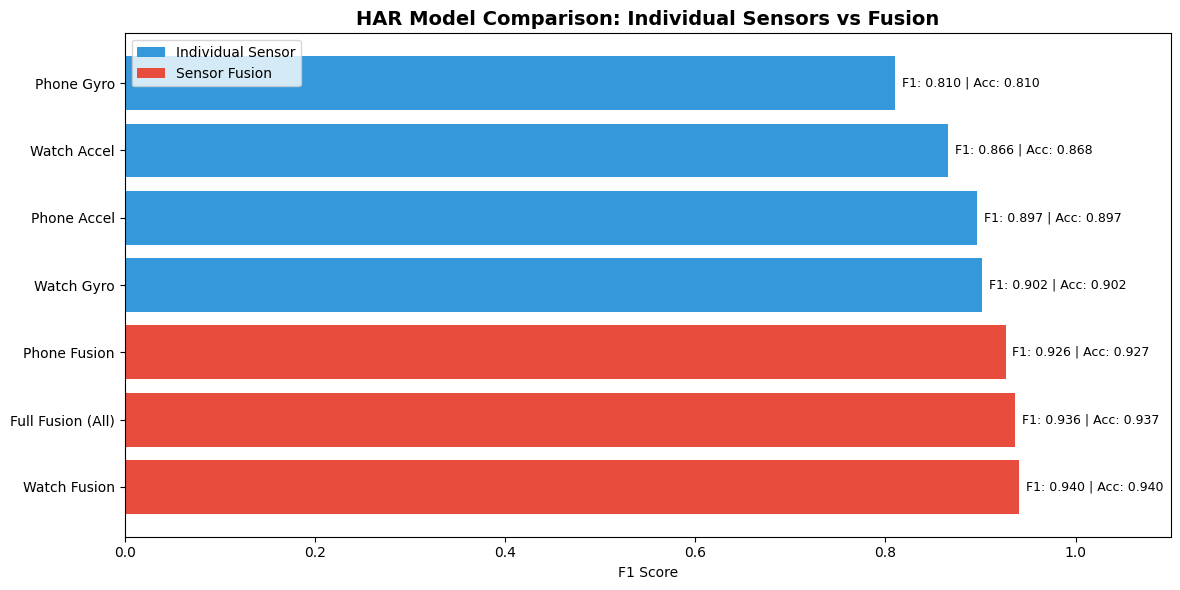

In [11]:
# Visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Color by type
colors = ['#3498db' if t == 'Individual' else '#e74c3c' for t in comparison_df['Type']]

bars = ax.barh(comparison_df['Approach'], comparison_df['F1 Score'], color=colors)
ax.set_xlabel('F1 Score')
ax.set_title('HAR Model Comparison: Individual Sensors vs Fusion', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1.1)

# Add value labels
for bar, acc in zip(bars, comparison_df['Accuracy']):
    width = bar.get_width()
    ax.annotate(f'F1: {width:.3f} | Acc: {acc:.3f}',
                xy=(width, bar.get_y() + bar.get_height()/2),
                xytext=(5, 0), textcoords='offset points',
                ha='left', va='center', fontsize=9)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498db', label='Individual Sensor'),
    Patch(facecolor='#e74c3c', label='Sensor Fusion')
]
ax.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(MODELS_PATH, 'fusion_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. 🏆 Best Model Selection

In [12]:
# Find overall best approach
best_row = comparison_df.iloc[0]

print("\n" + "="*60)
print("🏆 BEST OVERALL MODEL")
print("="*60)
print(f"   Approach: {best_row['Approach']}")
print(f"   Type: {best_row['Type']}")
print(f"   Model: {best_row['Best Model']}")
print(f"   Accuracy: {best_row['Accuracy']:.4f}")
print(f"   F1 Score: {best_row['F1 Score']:.4f}")
print("="*60)


🏆 BEST OVERALL MODEL
   Approach: Watch Fusion
   Type: Fusion
   Model: LightGBM
   Accuracy: 0.9401
   F1 Score: 0.9400


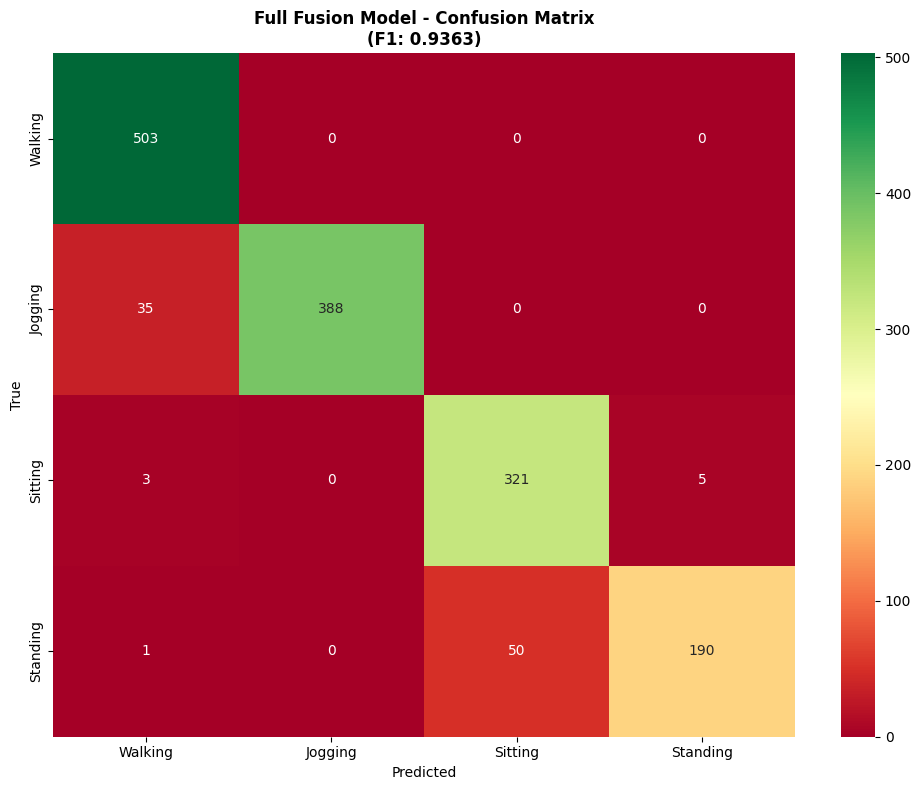


📋 Classification Report (Full Fusion):
              precision    recall  f1-score   support

     Walking       0.93      1.00      0.96       503
     Jogging       1.00      0.92      0.96       423
     Sitting       0.87      0.98      0.92       329
    Standing       0.97      0.79      0.87       241

    accuracy                           0.94      1496
   macro avg       0.94      0.92      0.93      1496
weighted avg       0.94      0.94      0.94      1496



In [13]:
# Confusion matrix for best fusion model
if full_fusion_result:
    plt.figure(figsize=(10, 8))
    
    cm = confusion_matrix(full_fusion_result['y_test'], full_fusion_result['y_pred'])
    class_names = [ACTIVITY_LABELS.get(c, c) for c in full_fusion_result['label_encoder'].classes_]
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Full Fusion Model - Confusion Matrix\n(F1: {full_fusion_result["f1"]:.4f})', 
              fontweight='bold')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.savefig(os.path.join(MODELS_PATH, 'fusion_confusion_matrix.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n📋 Classification Report (Full Fusion):")
    print(classification_report(full_fusion_result['y_test'], full_fusion_result['y_pred'], 
                               target_names=class_names))

## 7. 💾 Save Final Phase 1 Summary

In [14]:
# Complete Phase 1 summary
phase1_complete = {
    'individual_sensors': individual_results,
    'fusion_results': {
        'phone': {
            'model': phone_fusion_result['best_model_name'] if phone_fusion_result else None,
            'f1': phone_fusion_result['f1'] if phone_fusion_result else None
        },
        'watch': {
            'model': watch_fusion_result['best_model_name'] if watch_fusion_result else None,
            'f1': watch_fusion_result['f1'] if watch_fusion_result else None
        },
        'full': {
            'model': full_fusion_result['best_model_name'] if full_fusion_result else None,
            'f1': full_fusion_result['f1'] if full_fusion_result else None
        }
    },
    'best_overall': {
        'approach': best_row['Approach'],
        'type': best_row['Type'],
        'model': best_row['Best Model'],
        'accuracy': best_row['Accuracy'],
        'f1_score': best_row['F1 Score']
    },
    'activities': PRIMARY_ACTIVITIES,
    'activity_names': [ACTIVITY_LABELS.get(a, a) for a in PRIMARY_ACTIVITIES]
}

joblib.dump(phase1_complete, os.path.join(MODELS_PATH, 'phase1_complete_summary.joblib'))

print("\n" + "="*70)
print("🎉 PHASE 1 FULLY COMPLETE!")
print("="*70)
print(f"\n📁 Models Saved:")
print(f"   Individual Sensors:")
for sensor in ['phone_accel', 'phone_gyro', 'watch_accel', 'watch_gyro']:
    print(f"      ✅ har_{sensor}/")
print(f"   Fusion Models:")
print(f"      ✅ har_fusion_phone/")
print(f"      ✅ har_fusion_watch/")
print(f"      ✅ har_fusion_full/")
print(f"\n🏆 Best Approach: {best_row['Approach']} (F1: {best_row['F1 Score']:.4f})")
print(f"\n📊 Ready for Phase 2: Rule-Based Energy Estimation")
print("="*70)


🎉 PHASE 1 FULLY COMPLETE!

📁 Models Saved:
   Individual Sensors:
      ✅ har_phone_accel/
      ✅ har_phone_gyro/
      ✅ har_watch_accel/
      ✅ har_watch_gyro/
   Fusion Models:
      ✅ har_fusion_phone/
      ✅ har_fusion_watch/
      ✅ har_fusion_full/

🏆 Best Approach: Watch Fusion (F1: 0.9400)

📊 Ready for Phase 2: Rule-Based Energy Estimation


---
## 📋 Phase 1 Complete - Models Overview

```
Models/
├── har_phone_accel/           # Individual: Phone Accelerometer
├── har_phone_gyro/            # Individual: Phone Gyroscope
├── har_watch_accel/           # Individual: Watch Accelerometer
├── har_watch_gyro/            # Individual: Watch Gyroscope
├── har_fusion_phone/          # Fusion: Phone (Accel + Gyro)
├── har_fusion_watch/          # Fusion: Watch (Accel + Gyro)
├── har_fusion_full/           # Fusion: All Sensors
├── phase1_summary.joblib      # Individual sensor summary
├── phase1_complete_summary.joblib  # Complete Phase 1 summary
├── sensor_comparison.png
├── fusion_comparison.png
└── fusion_confusion_matrix.png
```

---
*Phase 1 Complete - Proceed to Phase 2: Rule-Based Energy Estimation*